# 🔍 Implémentation TF-IDF - Baseline

Ce notebook implémente notre modèle baseline **TF-IDF** pour la recherche d'information sur le dataset TREC-COVID.

## Objectifs
- Charger le dataset TREC-COVID
- Implémenter TF-IDF pour indexer le corpus
- Utiliser les fonctions généralistes pour la recherche et l'évaluation
- Évaluer les performances avec NDCG@10


## 📦 1. Imports et Configuration


In [1]:
# Imports nécessaires
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from beir.datasets.data_loader import GenericDataLoader

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports terminés")


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\beir\datasets\data_loader.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


✓ Imports terminés


## 📂 2. Chargement des Données


# Chemin vers le dataset TREC-COVID
data_path = "data/trec-covid/trec-covid"

# Vérifier que le dataset existe
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset introuvable à {data_path}. Exécutez d'abord download.py")

print(f"Chargement du dataset depuis: {data_path}")


In [8]:
# Charger les données avec BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus chargé: {len(corpus)} documents")
print(f"✓ Requêtes chargées: {len(queries)} requêtes")
print(f"✓ Qrels chargés: {len(qrels)} jugements de pertinence")


100%|██████████| 171332/171332 [00:01<00:00, 124012.16it/s]


✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [9]:
# Afficher un exemple de document et de requête
print("Exemple de document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Titre: {doc['title'][:100]}...")
print(f"Texte: {doc['text'][:200]}...")

print("\nExemple de requête:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Texte: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


In [10]:
## 🔧 3. Préparation des Données


### 3.1. Préparation des Documents


In [11]:
# Préparer les documents pour TF-IDF
# On combine titre et texte pour avoir plus de contexte
documents = []
doc_ids = []

for doc_id, doc in corpus.items():
    # Combiner titre et texte
    full_text = f"{doc['title']} {doc['text']}"
    documents.append(full_text)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents préparés")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents]):.0f} caractères")


✓ 171332 documents préparés
✓ Longueur moyenne: 1118 caractères


## 🎯 4. Implémentation TF-IDF


**TF-IDF** (Term Frequency-Inverse Document Frequency) :
- **TF** : Fréquence du terme dans le document
- **IDF** : Inverse de la fréquence du terme dans tout le corpus
- Plus un mot est rare dans le corpus mais fréquent dans un document, plus son score TF-IDF est élevé


### 4.1. Création du Vectorizer TF-IDF

**TF-IDF** (Term Frequency-Inverse Document Frequency) :
- **TF** : Fréquence du terme dans le document
- **IDF** : Inverse de la fréquence du terme dans tout le corpus
- Plus un mot est rare dans le corpus mais fréquent dans un document, plus son score TF-IDF est élevé


In [14]:
# Créer le vectorizer TF-IDF
# Paramètres :
# - lowercase=True : convertir en minuscules
# - stop_words='english' : supprimer les mots vides (the, a, an, etc.)
# - max_features=50000 : limiter à 50000 mots les plus fréquents (pour la performance)
# - ngram_range=(1,2) : utiliser des unigrammes et bigrammes (ex: "COVID-19" sera capturé)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,  # Ignorer les mots qui apparaissent dans moins de 2 documents
    max_df=0.95  # Ignorer les mots qui apparaissent dans plus de 95% des documents
)

print("✓ Vectorizer TF-IDF créé")


✓ Vectorizer TF-IDF créé


### 4.2. Indexation du Corpus


In [16]:
# Transformer les documents en vecteurs TF-IDF
print("Indexation du corpus avec TF-IDF...")
print("(Cela peut prendre quelques minutes pour 171k documents)")

doc_vectors = vectorizer.fit_transform(documents)

print(f"✓ Corpus indexé")
print(f"  - Forme de la matrice: {doc_vectors.shape}")
print(f"  - Nombre de features (mots): {doc_vectors.shape[1]}")
print(f"  - Matrice creuse: {doc_vectors.nnz / (doc_vectors.shape[0] * doc_vectors.shape[1]) * 100:.2f}% de valeurs non-nulles")


Indexation du corpus avec TF-IDF...
(Cela peut prendre quelques minutes pour 171k documents)
✓ Corpus indexé
  - Forme de la matrice: (171332, 50000)
  - Nombre de features (mots): 50000
  - Matrice creuse: 0.18% de valeurs non-nulles


## 🔍 5. Recherche de Documents Pertinents


### 5.1. Test de Recherche sur une Requête

Nous utilisons la fonction généraliste `search()` de `functions.py` qui fonctionne avec n'importe quel vectorizer.


In [17]:
# Tester la fonction search() sur la première requête
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Requête test: {test_query_id}")
print(f"Texte: {test_query_text}\n")

# Utiliser la fonction généraliste search()
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents trouvés:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc u7u75sl0 (score: 0.6155)
   Titre: Strategies to trace back the origin of COVID-19...

2. Doc dv9m19yk (score: 0.5738)
   Titre: [What is the origin of SARS-CoV-2?]...

3. Doc rugiaioi (score: 0.5600)
   Titre: The scandals of covid-19...

4. Doc k94ywblf (score: 0.5600)
   Titre: Når covid-19 møter afrikansk helsevesen...

5. Doc rp6r1fqy (score: 0.5600)
   Titre: COVID-19 zeigt Nerven...

6. Doc 3lsixdti (score: 0.5600)
   Titre: COVID-19 – Where should we go now?...

7. Doc talqe17m (score: 0.5600)
   Titre: LEVEN TIJDENS COVID-19...

8. Doc wy0y5ztd (score: 0.5600)
   Titre: Covid-19...

9. Doc anqswymg (score: 0.5600)
   Titre: Covid-19 and decarceration....

10. Doc oll7cw6h (score: 0.5600)
   Titre: COVID ‐19 and the gastroenterologist...



### 5.2. Comparaison avec le Top 10 Idéal

Comparons les résultats du modèle avec le top 10 idéal basé sur les Qrels.


In [18]:
# Comparer les résultats du modèle avec le top 10 idéal
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Obtenir les résultats du modèle
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Obtenir le top 10 idéal
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARAISON POUR LA REQUÊTE {test_query_id}")
print(f"Texte: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETOURNÉ PAR LE MODÈLE TF-IDF:")
print("-" * 80)
for i, (doc_id, tfidf_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score TF-IDF: {tfidf_score:.4f} | Pertinence réelle: {relevance}")
    print(f"    Titre: {doc['title'][:70]}...")

print("\n✅ TOP 10 IDÉAL (selon les Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score de pertinence: {relevance_score}")
    print(f"    Titre: {doc['title'][:70]}...")

# Calculer le score NDCG@10 pour cette requête avec evaluate_single_query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 Score NDCG@10 pour cette requête: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE TF-IDF:
--------------------------------------------------------------------------------
 1. Doc u7u75sl0 | Score TF-IDF: 0.6155 | Pertinence réelle: 1
    Titre: Strategies to trace back the origin of COVID-19...
 2. Doc dv9m19yk | Score TF-IDF: 0.5738 | Pertinence réelle: 1
    Titre: [What is the origin of SARS-CoV-2?]...
 3. Doc rugiaioi | Score TF-IDF: 0.5600 | Pertinence réelle: 0
    Titre: The scandals of covid-19...
 4. Doc k94ywblf | Score TF-IDF: 0.5600 | Pertinence réelle: 0
    Titre: Når covid-19 møter afrikansk helsevesen...
 5. Doc rp6r1fqy | Score TF-IDF: 0.5600 | Pertinence réelle: 0
    Titre: COVID-19 zeigt Nerven...
 6. Doc 3lsixdti | Score TF-IDF: 0.5600 | Pertinence réelle: 0
    Titre: COVID-19 – Where should we go now?...
 7. Doc talqe17m | Score TF-IDF: 0.5600 | Pertinence réelle: 0
    Titre: LEVEN TIJDENS COVID-19...
 8. Doc wy0y5ztd | Score TF-IDF: 0.5600 | 

### 5.3. Recherche sur Toutes les Requêtes


In [19]:
# Rechercher les documents pertinents pour toutes les requêtes
print("Recherche sur toutes les requêtes...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Évaluation avec NDCG@10


In [20]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.5868
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.3350
Number of queries: 50


### 6.1. Distribution des Scores


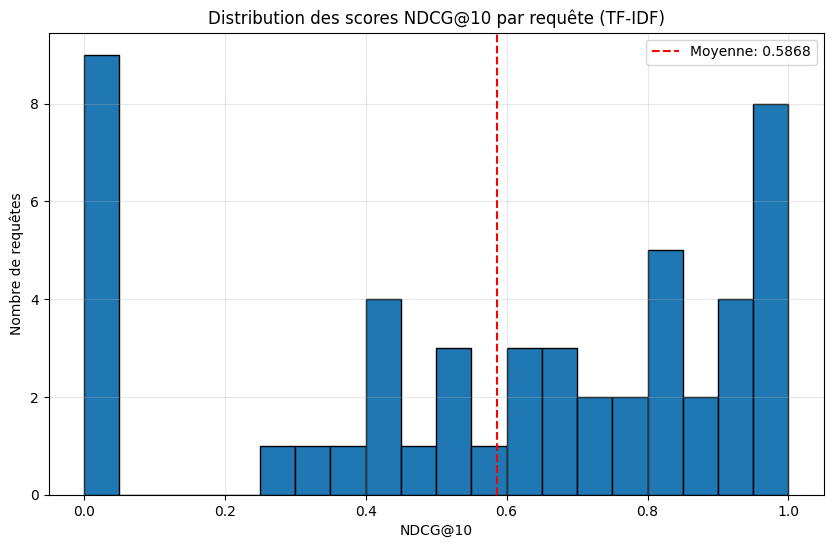

In [21]:
# Afficher la distribution des scores NDCG@10
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Nombre de requêtes')
plt.title('Distribution des scores NDCG@10 par requête (TF-IDF)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Moyenne: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Analyse des Résultats


In [27]:
# Afficher les meilleures et pires requêtes
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 meilleures requêtes:")
print(ndcg_df.head())
print("\nTop 5 pires requêtes:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
0         1  1.000000
22       23  1.000000
42       43  0.978531
21       22  0.970569
40       41  0.970544

Top 5 pires requêtes:
   query_id  ndcg@10
26       27      0.0
30       31      0.0
34       35      0.0
47       48      0.0
46       47      0.0


In [28]:
# Analyser une requête avec un bon score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nRequête avec le meilleur NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Texte: {best_query_text}\n")

# Obtenir les résultats du modèle pour cette requête depuis all_model_results
model_results = all_model_results[best_query_id]

print("Top 5 documents retournés:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (score TF-IDF: {score:.4f}, pertinence réelle: {relevance})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (1.0000):
ID: 1
Texte: what is the origin of COVID-19

Top 5 documents retournés:
1. Doc u7u75sl0 (score TF-IDF: 0.6155, pertinence réelle: 1)
   Titre: Strategies to trace back the origin of COVID-19...

2. Doc dv9m19yk (score TF-IDF: 0.5738, pertinence réelle: 1)
   Titre: [What is the origin of SARS-CoV-2?]...

3. Doc rugiaioi (score TF-IDF: 0.5600, pertinence réelle: 0)
   Titre: The scandals of covid-19...

4. Doc k94ywblf (score TF-IDF: 0.5600, pertinence réelle: 0)
   Titre: Når covid-19 møter afrikansk helsevesen...

5. Doc rp6r1fqy (score TF-IDF: 0.5600, pertinence réelle: 0)
   Titre: COVID-19 zeigt Nerven...



## 💾 8. Sauvegarde des Résultats


In [32]:
# Sauvegarder les résultats pour comparaison future avec Word2Vec
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/tfidf_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Sauvegarder le résumé
summary = {
    "model": "TF-IDF",
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids)
}

with open(f"{results_dir}/tfidf_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - tfidf_ndcg_scores.json")
print(f"  - tfidf_summary.json")


✓ Résultats sauvegardés dans results/
  - tfidf_ndcg_scores.json
  - tfidf_summary.json
